In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.cluster as KMeans
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\arnav\Downloads\Projects\Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

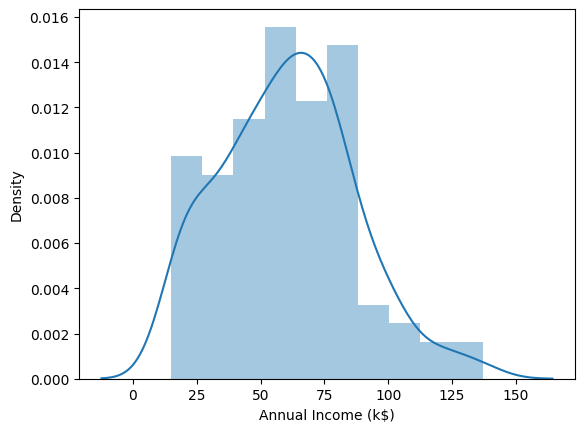

In [6]:
sns.distplot(df['Annual Income (k$)'	])

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

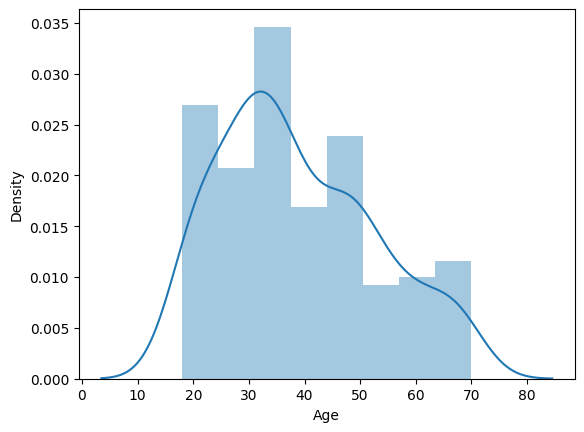

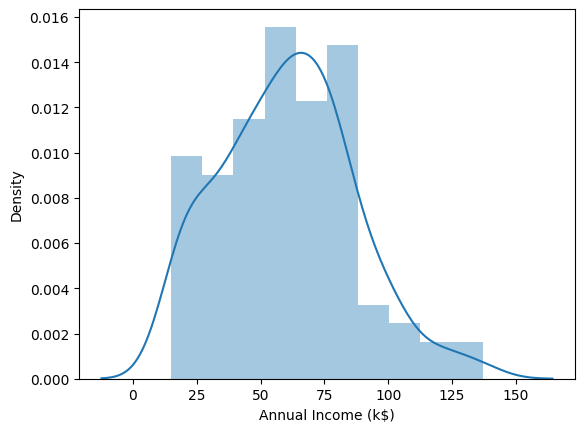

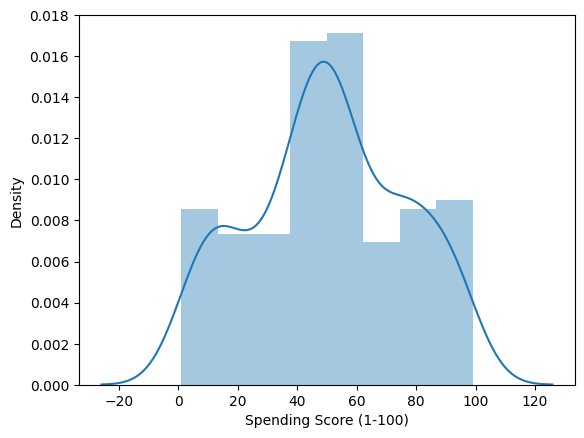

In [8]:
columns = [ 'Age', 'Annual Income (k$)','Spending Score (1-100)']
for i in columns:
    plt.figure()
    sns.distplot(df[i])

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

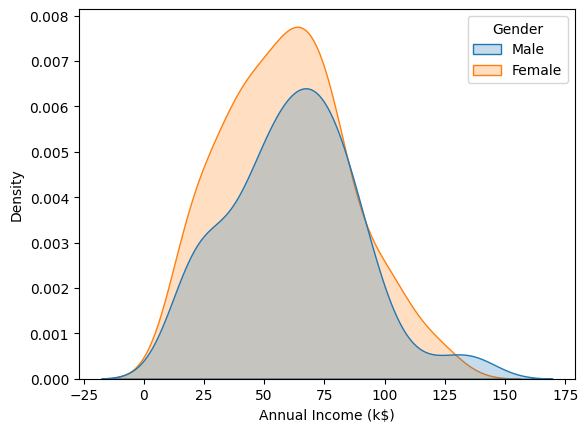

In [9]:
sns.kdeplot(
    data=df,
    x="Annual Income (k$)",
    hue="Gender",
    fill=True 
)

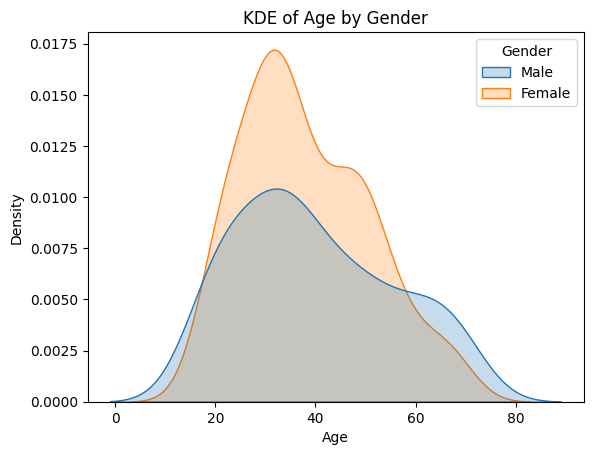

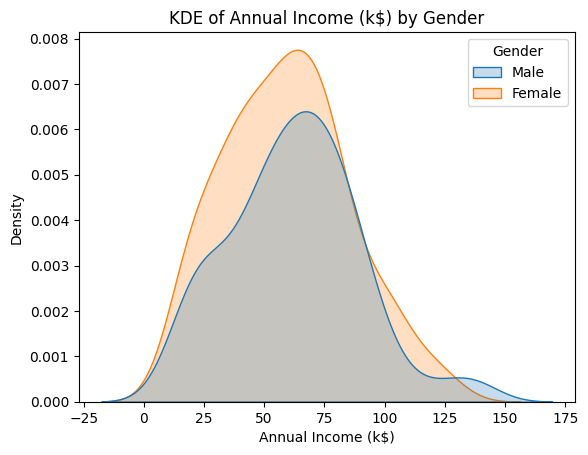

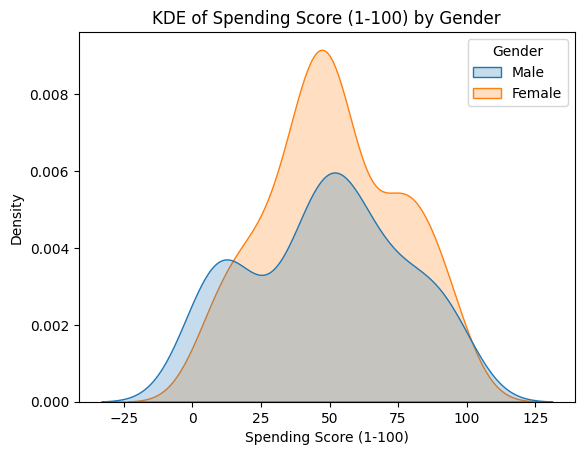

In [10]:


for i in columns:   # columns is your list of column names
    plt.figure()
    sns.kdeplot(
        data=df,
        x=i,              # pass the column name directly, not [i]
        hue="Gender",
        fill=True
    )
    plt.title(f"KDE of {i} by Gender")
    plt.show()

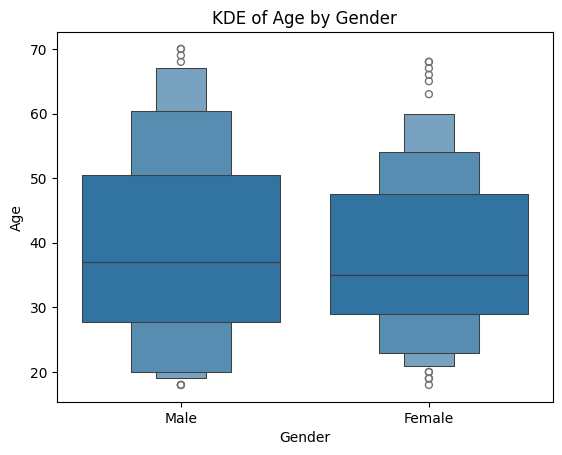

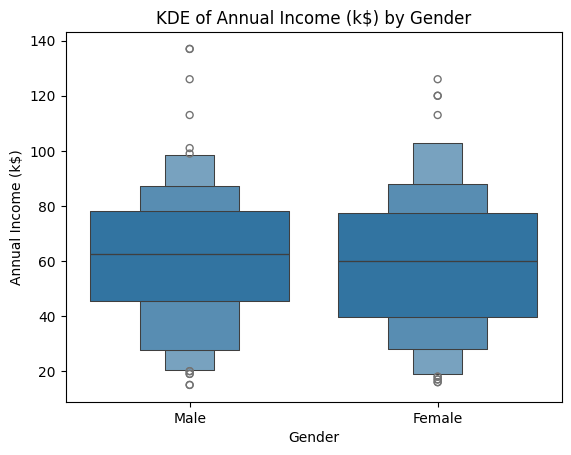

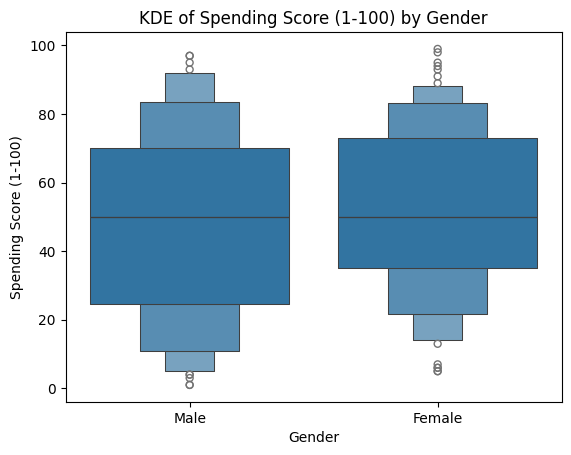

In [11]:
for i in columns:   # columns is your list of column names
    plt.figure()
    sns.boxenplot(
        data=df,
        x='Gender',
        y=df[i])
    plt.title(f"KDE of {i} by Gender")
    plt.show()

In [12]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

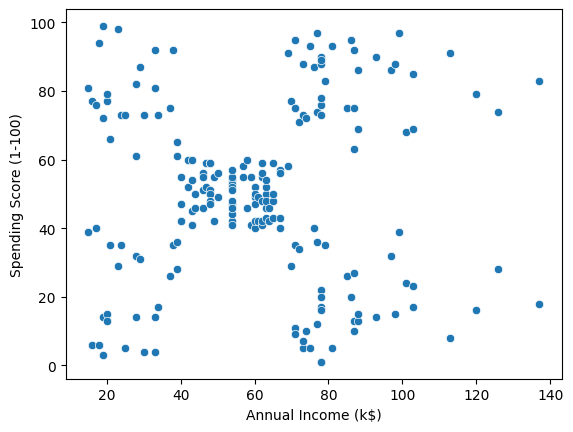

In [13]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)')

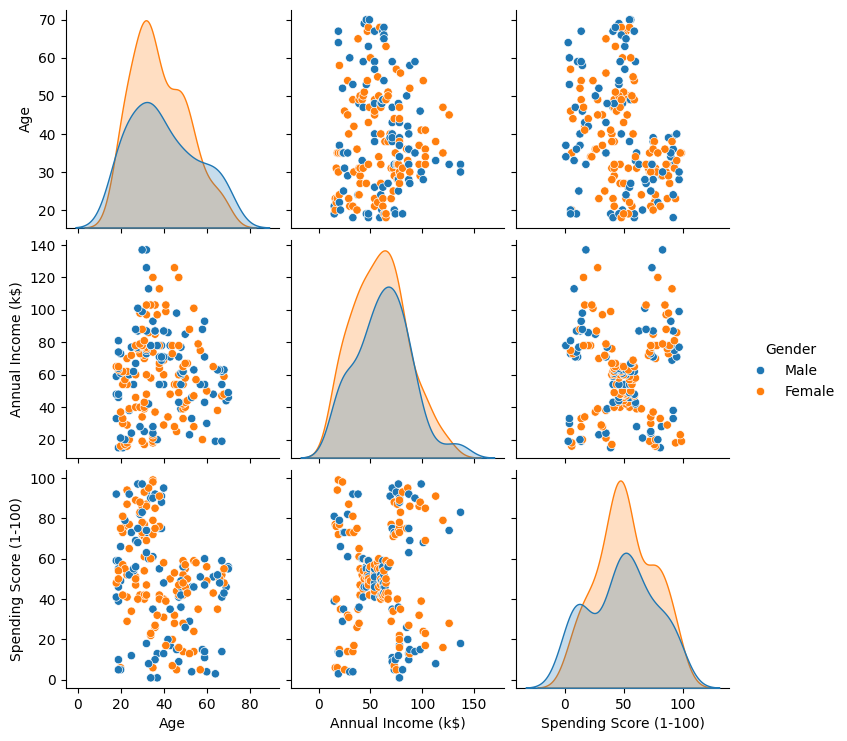

In [15]:
#df = df.drop('CustomerID',axis=1)
sns.pairplot(df,hue='Gender')

In [19]:
df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [21]:
df.corr(numeric_only=True)


,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


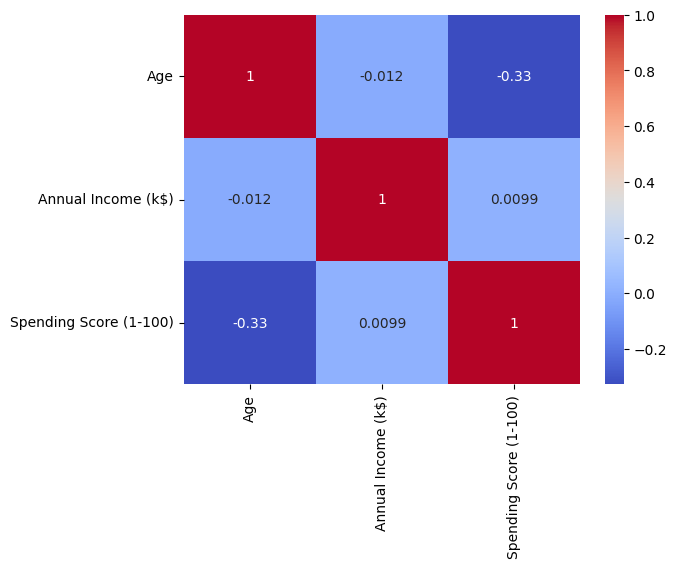

In [26]:


sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [31]:
from sklearn.cluster import KMeans

# Now you can create a model instance
clustering1 = KMeans(n_clusters=3, random_state=42)


In [32]:
clustering1.fit(df[['Annual Income (k$)']])

KMeans(n_clusters=3, random_state=42)

In [33]:
clustering1.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [34]:
df['Income Cluster'] = clustering1.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,Male,19,15,39,2
1,Male,21,15,81,2
2,Female,20,16,6,2
3,Female,23,16,77,2
4,Female,31,17,40,2


In [35]:
df['Income Cluster'].value_counts

<bound method IndexOpsMixin.value_counts of 0      2
1      2
2      2
3      2
4      2
      ..
195    1
196    1
197    1
198    1
199    1
Name: Income Cluster, Length: 200, dtype: int32>

In [36]:
clustering1.inertia_

25640.457784396836

In [38]:
inertia_scores=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)']])
    inertia_scores.append(kmeans.inertia_)

In [39]:
inertia_scores

[137277.28000000003,
 49761.73701298701,
 25640.457784396836,
 13278.112713472488,
 9413.731527093596,
 5496.533937621833,
 4189.555952380953,
 3387.8033422459894,
 2470.271840251252,
 1875.6048118548117]

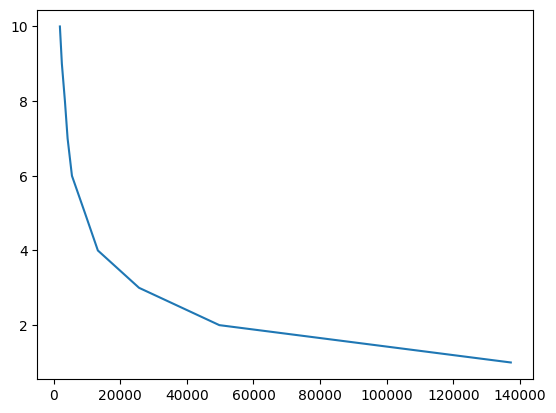

In [40]:
plt.plot(inertia_scores,range(1,11))

In [41]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Income Cluster'],
      dtype='object')

In [43]:
df.groupby('Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()



,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,41.279070,60.906977,50.337209
1,36.910714,92.142857,50.517857
2,37.120690,29.551724,49.689655


In [44]:
clustering2 = KMeans()
clustering2.fit(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
df['Spending and Income Cluster'] = clustering2.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,2,0
1,Male,21,15,81,2,4
2,Female,20,16,6,2,6
3,Female,23,16,77,2,4
4,Female,31,17,40,2,0


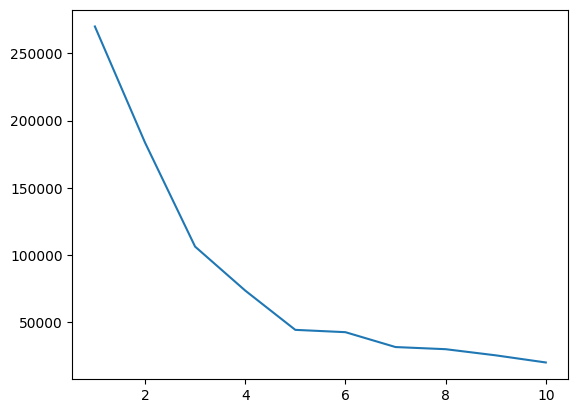

In [46]:
inertia_scores2=[]
for i in range(1,11):
    kmeans2=KMeans(n_clusters=i)
    kmeans2.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
    inertia_scores2.append(kmeans2.inertia_)
plt.plot(range(1,11),inertia_scores2)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

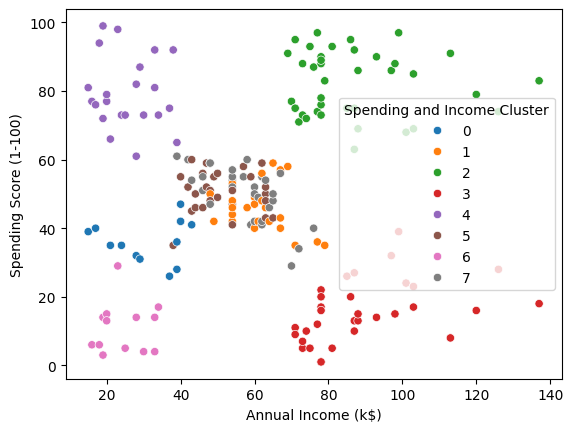

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatterplot of customers colored by cluster
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Spending and Income Cluster',
    palette='tab10'
)

# Overlay cluster centers as black stars
centers = clustering1.cluster_centers_
plt.scatter(
    x=centers['x'],
    y=centers['y'],
    s=200,          # larger size for visibility
    c='black',
    marker='*',
    edgecolor='white'  # optional: white outline for contrast
)

plt.title("Customer Segments with Cluster Centers")
plt.show()


In [52]:
pd.crosstab(df['Spending and Income Cluster'],df['Gender'],normalize='index')

Gender,Female,Male
Spending and Income Cluster,,
0,0.692308,0.307692
1,0.666667,0.333333
2,0.538462,0.461538
3,0.437500,0.562500
4,0.590909,0.409091
5,0.518519,0.481481
6,0.538462,0.461538
7,0.600000,0.400000


In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scale = StandardScaler()

In [56]:
dff = pd.get_dummies(df,drop_first=True)
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Gender_Male
0,19,15,39,2,0,True
1,21,15,81,2,4,True
2,20,16,6,2,6,False
3,23,16,77,2,4,False
4,31,17,40,2,0,False


In [57]:
dff = dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)','Gender_Male']]
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [58]:
dff = scale.fit_transform(dff)

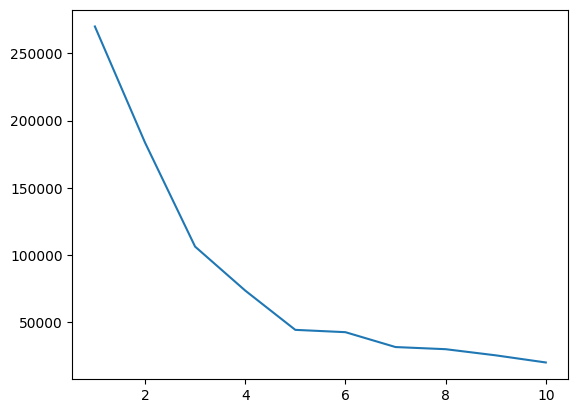

In [59]:
inertia_scores3=[]
for i in range(1,11):
    kmeans3=KMeans(n_clusters=i)
    kmeans3.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
    inertia_scores3.append(kmeans3.inertia_)
plt.plot(range(1,11),inertia_scores2)

In [60]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,2,0
1,Male,21,15,81,2,4
2,Female,20,16,6,2,6
3,Female,23,16,77,2,4
4,Female,31,17,40,2,0
...,...,...,...,...,...,...
195,Female,35,120,79,1,2
196,Female,45,126,28,1,3
197,Male,32,126,74,1,2
198,Male,32,137,18,1,3
